In [8]:
import os

from IPython.core.magics import config
from dotenv import load_dotenv, find_dotenv

#load_dotenv(find_dotenv())

# os.environ["LANGCHAIN_TRACING_V2"] = os.getenv("LANGSMITH_TRACING", "false")
# os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGSMITH_API_KEY", "")
# os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGSMITH_PROJECT", "default")

In [9]:
import requests
from IPython.display import display, Image
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate
from langgraph.graph import MessagesState, StateGraph, START, END
from pydantic import BaseModel, Field

from langchain_core.tracers import LangChainTracer

#tracer = LangChainTracer(project_name="langgraph-trails")
#re_config={"configurable":{"thread_id":"reason_cc"},"callbacks": [tracer]}

In [10]:
llm = init_chat_model(model="mistral:latest", model_provider="ollama", temperature=0.0)

CONVERSION_SYSTEM_PROMPT = """You extract currency conversion details from user messages.
Return structured fields only — do not invent values.

Rules:
- ONLY extract when the user explicitly asks to CONVERT currency from one currency to another.
  Valid examples: "convert 520 from INR to USD", "how much is 100 euros in dollars", "what is 200 rupees in yen"
  NOT conversion: travel plans, expenses, prices, or messages that only mention an amount.
- Key signals that make a message NOT a conversion request:
  - Words like "trip", "travel", "travelling", "going to", "visiting"
  - "from X to Y" used in a travel context (describing a journey, not a currency swap)
  - General statements mentioning money without explicitly asking for a conversion
  - Topics unrelated to currency exchange
- If it IS a conversion request, extract:
  - amount: the numeric value to convert
  - from_ccode: ISO 4217 code for the currency the user HAS (source)
  - to_ccode: ISO 4217 code for the currency the user WANTS (target)
- Map common names to ISO codes:
  indian/inr/rupee/rs -> INR
  american/us/dollar/usa/america -> USD
  british/uk/pound/sterling -> GBP
  european/euro -> EUR
  chinese/china/cny/yuan -> CNY
  japanese/japan/jpy/yen -> JPY
- If the message is NOT an explicit currency conversion request, set amount=0, from_ccode="N_A", to_ccode="N_A"
- Use ONLY values from the user message. Never use example values unless the user said them.

Few-shot examples:
  "convert 520 INR to USD"            -> amount=520,  from_ccode=INR, to_ccode=USD  (explicit)
  "how much is 100 euros in dollars"  -> amount=100,  from_ccode=EUR, to_ccode=USD  (explicit)
  "what is 200 rupees in yen"         -> amount=200,  from_ccode=INR, to_ccode=JPY  (explicit)
  "i have 200 from china to japan"    -> amount=0,    from_ccode=N_A, to_ccode=N_A  (travel)
  "i have 200 to trip to india to US" -> amount=0,    from_ccode=N_A, to_ccode=N_A  (travel)
  "travelling to US with Rs. 5000"    -> amount=0,    from_ccode=N_A, to_ccode=N_A  (travel)
  "tendulkar hits 100 today"          -> amount=0,    from_ccode=N_A, to_ccode=N_A  (unrelated)"""

SUMMARIZE_HUMAN_PROMPT = """
    Here is a currency conversion result: {raw_response}.
    Please convert it into a clear, human-readable sentence.
    """

conversion_prompt = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template(CONVERSION_SYSTEM_PROMPT),
    HumanMessagePromptTemplate.from_template("{question}"),
])

summary_prompt = ChatPromptTemplate.from_messages([HumanMessagePromptTemplate.from_template(SUMMARIZE_HUMAN_PROMPT)])

DATA_CONVERSION_AGENT = "data_conversion_agent"
CURRENCY_API_NODE = "fetch_exchange_rate"
SUMMARIZE_CONVERSION_AGENT = "summarize_conversion_agent"

In [11]:
class CCResponse(BaseModel):
    amount: float = Field(description="The numeric amount to convert from the user message")
    from_ccode: str = Field(description="ISO 4217 3-letter source currency code", max_length=3)
    to_ccode: str = Field(description="ISO 4217 3-letter target currency code", max_length=3)


class ConversionState(MessagesState):
    action_type: str | None
    amount: float | None
    from_cc: str | None
    to_cc: str | None
    rate: float | None

In [12]:
# Built once at module level — not recreated on every graph invocation
structured_llm = llm.with_structured_output(CCResponse)
extraction_chain = conversion_prompt | structured_llm
summary_chain = summary_prompt | llm


def conversion_agent(state: ConversionState):
    msg = state["messages"][-1].content
    result: CCResponse = extraction_chain.invoke({"question": msg})
    print(f"conversion_agent: {result}")
    is_conversion = result.from_ccode != "N_A" and result.to_ccode != "N_A"
    if is_conversion:
        return {
            "action_type": "USE_CC",
            "amount": result.amount,
            "from_cc": result.from_ccode,
            "to_cc": result.to_ccode,
        }
    return {"action_type": "NO_CC"}


def currency_conversion(state: ConversionState):
    cc_url = f"https://api.frankfurter.dev/v1/latest?from={state['from_cc']}&to={state['to_cc']}&amount={state['amount']}"
    response = requests.get(cc_url, timeout=10)
    if response.status_code == 200:
        res_value = response.json()
        converted_rate = list(res_value["rates"].values())[0]
        return {
            "action_type": "CONVERTED",
            "rate": converted_rate
        }
    return {"action_type": "CONVERSION_ERROR"}


def summarize_conversion(state: ConversionState):
    if state["action_type"] == "CONVERTED":
        raw_response = f"Amount: {state['amount']} | From Currency Code: {state['from_cc']} | To Currency Code: {state['to_cc']} | Converted Rate: {state['rate']} "
        summary_report = summary_chain.invoke({"raw_response": raw_response})
        return {"messages": [summary_report]}
    elif state["action_type"] == "CONVERSION_ERROR":
        return {"messages": [AIMessage(content="Sorry, I couldn't fetch the conversion rate. Please try again later.")]}
    elif state["action_type"] == "NO_CC":
        return {"messages": [AIMessage(content="That doesn't look like a currency conversion request. Try something like: 'convert 100 USD to EUR'.")]}
    else:
        raise ValueError(f"summarize_conversion reached with unexpected action_type: {state['action_type']}")

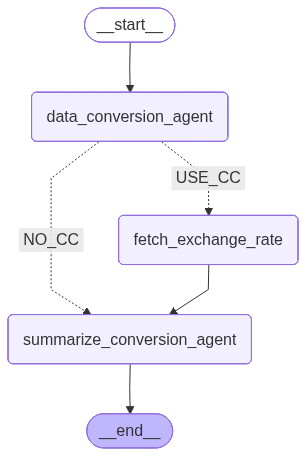

In [13]:
wf_builder = StateGraph(ConversionState)
wf_builder.add_node(DATA_CONVERSION_AGENT, conversion_agent)
wf_builder.add_node(CURRENCY_API_NODE, currency_conversion)
wf_builder.add_node(SUMMARIZE_CONVERSION_AGENT, summarize_conversion)

wf_builder.add_edge(START, DATA_CONVERSION_AGENT)
wf_builder.add_conditional_edges(DATA_CONVERSION_AGENT, lambda state: state['action_type'], {
    "USE_CC": CURRENCY_API_NODE,
    "NO_CC": SUMMARIZE_CONVERSION_AGENT,
})
wf_builder.add_edge(CURRENCY_API_NODE, SUMMARIZE_CONVERSION_AGENT)
wf_builder.add_edge(SUMMARIZE_CONVERSION_AGENT, END)
graph = wf_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
while True:
    u_input = input("User: ").strip()
    if not u_input:
        continue
    if u_input == "/bye":
        print("Thank you!")
        break
    res = graph.invoke(
        {"messages": [HumanMessage(u_input)]},
       # config= re_config
       # config={"callbacks": [tracer]}
    )
    for m in res["messages"]:
        m.pretty_print()

conversion_agent: amount=100.0 from_ccode='INR' to_ccode='HKD'
================================ Human Message =================================

convert rs 100 into honkong currency
================================== Ai Message ==================================

 The equivalent of 100 Indian Rupees (INR) in Hong Kong Dollars (HKD) is approximately 825.05 Hong Kong Dollars, given the conversion rate of 8.2505.
Thank you!
